# 🔄 Week 4 · Day 2 — Cross-Validation
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 · Week 4 of 10 · Day 2 of 5**

## 🎯 Learning Objectives
- 🧠 Explain how k-fold cross-validation produces a reliable performance estimate.
- ⚙️ Run cross-validation with `cross_val_score` and interpret the mean and standard deviation.
- ⚖️ Explain why stratified k-fold matters for classification.

## 🧭 Today's Hands-On Lab
1. 🌳 Take the Day 1 model and evaluate it with 5-fold cross-validation using `cross_val_score`.
2. 📊 Report the mean and standard deviation of the scores across folds.
3. 🔍 Compare the cross-validated estimate to the single-split score from Day 1 and explain any difference.
4. ⚖️ For this classification task, confirm stratified folds are used and explain why that matters here.

> 💡 This notebook continues on the same Breast Cancer dataset and `RandomForestClassifier` from Day 1, so the comparison to yesterday's single validation split is apples-to-apples.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load Data and Recreate Day 1's Split 📦
Same dataset, same `random_state` as Day 1, so the training set here is identical to yesterday's.


In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# same three-way split logic as Day 1
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

# Day 1's chosen hyperparameter (best_depth found via validation set)
day1_best_depth = 3
day1_val_f1 = None  # filled in after we recompute it below for a fair comparison

print(f"Train set: {X_train.shape[0]} rows")
print(f"Val set:   {X_val.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows (still untouched)")


Train set: 341 rows
Val set:   114 rows
Test set:  114 rows (still untouched)


## 2️⃣ Recall Yesterday's Single-Split Result 🎯
Yesterday we picked `max_depth=3` by checking **one** validation split. Let's recompute that score so we have a clean number to compare against cross-validation.


In [3]:
single_split_model = RandomForestClassifier(max_depth=day1_best_depth, random_state=RANDOM_STATE)
single_split_model.fit(X_train, y_train)

from sklearn.metrics import f1_score
day1_val_f1 = f1_score(y_val, single_split_model.predict(X_val))

print(f"Day 1 single validation-split F1 (max_depth={day1_best_depth}): {day1_val_f1:.4f}")


Day 1 single validation-split F1 (max_depth=3): 0.9650


## 3️⃣ Step 1 — Evaluate With 5-Fold Cross-Validation 🔄

Instead of trusting one lucky-or-unlucky validation split, `cross_val_score` rotates through 5 folds,
training on 4 and validating on 1 each time.


In [4]:
cv_model = RandomForestClassifier(max_depth=day1_best_depth, random_state=RANDOM_STATE)

cv_scores = cross_val_score(cv_model, X_train, y_train, cv=5, scoring="f1")

print("Fold scores:", np.round(cv_scores, 4))
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1:  {cv_scores.std():.4f}")


Fold scores: [0.9773 0.9535 0.9767 0.9318 0.9639]
Mean F1: 0.9606
Std F1:  0.0169


### 📈 Fold-by-Fold Scores

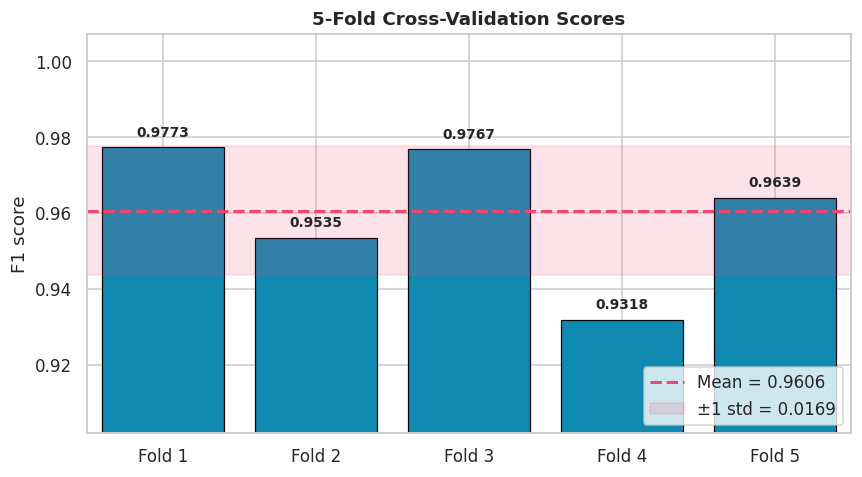

In [5]:
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(fold_labels, cv_scores, color="#118ab2", edgecolor="black", linewidth=0.8)

for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.003, f"{score:.4f}",
            ha="center", fontweight="bold", fontsize=9)

ax.axhline(cv_scores.mean(), color="#ef476f", linestyle="--", linewidth=2,
           label=f"Mean = {cv_scores.mean():.4f}")
ax.fill_between([-0.5, len(cv_scores) - 0.5],
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 color="#ef476f", alpha=0.15, label=f"±1 std = {cv_scores.std():.4f}")

ax.set_xlim(-0.5, len(cv_scores) - 0.5)
ax.set_ylim(min(cv_scores) - 0.03, max(cv_scores) + 0.03)
ax.set_ylabel("F1 score")
ax.set_title("5-Fold Cross-Validation Scores", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### ⚖️ Single Split (Day 1) vs. Cross-Validation (Day 2)

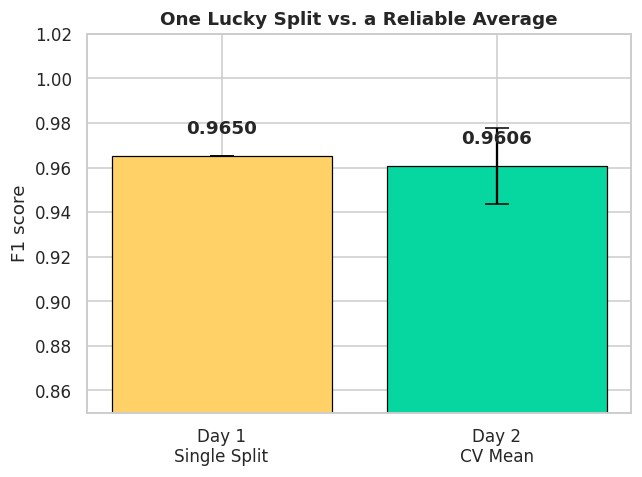

Day 1 single-split F1: 0.9650
Day 2 CV mean F1:      0.9606  (± 0.0169)
Difference: 0.0044


In [6]:
compare_labels = ["Day 1\nSingle Split", "Day 2\nCV Mean"]
compare_values = [day1_val_f1, cv_scores.mean()]
compare_errors = [0, cv_scores.std()]
compare_colors = ["#ffd166", "#06d6a0"]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(compare_labels, compare_values, yerr=compare_errors, capsize=8,
               color=compare_colors, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, compare_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.4f}",
            ha="center", fontweight="bold")

ax.set_ylim(0.85, 1.02)
ax.set_ylabel("F1 score")
ax.set_title("One Lucky Split vs. a Reliable Average", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Day 1 single-split F1: {day1_val_f1:.4f}")
print(f"Day 2 CV mean F1:      {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")
print(f"Difference: {abs(day1_val_f1 - cv_scores.mean()):.4f}")


## 4️⃣ Step 2 — Confirm Stratified Folds for Classification ⚖️

`cross_val_score` uses `StratifiedKFold` automatically for classifiers, which preserves the class balance
in every fold. Let's prove that by inspecting the class proportions fold-by-fold, and compare against what
plain (non-stratified) `KFold` would have produced.


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_train_arr = y_train.reset_index(drop=True)

strat_props, plain_props = [], []
for _, val_idx in skf.split(X_train, y_train_arr):
    strat_props.append(y_train_arr.iloc[val_idx].mean())
for _, val_idx in kf.split(X_train):
    plain_props.append(y_train_arr.iloc[val_idx].mean())

overall_prop = y_train_arr.mean()
print(f"Overall benign proportion in training data: {overall_prop:.4f}")
print("Stratified fold proportions:", np.round(strat_props, 4))
print("Plain KFold fold proportions:", np.round(plain_props, 4))


Overall benign proportion in training data: 0.6276
Stratified fold proportions: [0.6232 0.6324 0.6324 0.6324 0.6176]
Plain KFold fold proportions: [0.6377 0.5441 0.6324 0.6176 0.7059]


### 🎨 Stratified vs. Plain K-Fold — Class Balance per Fold

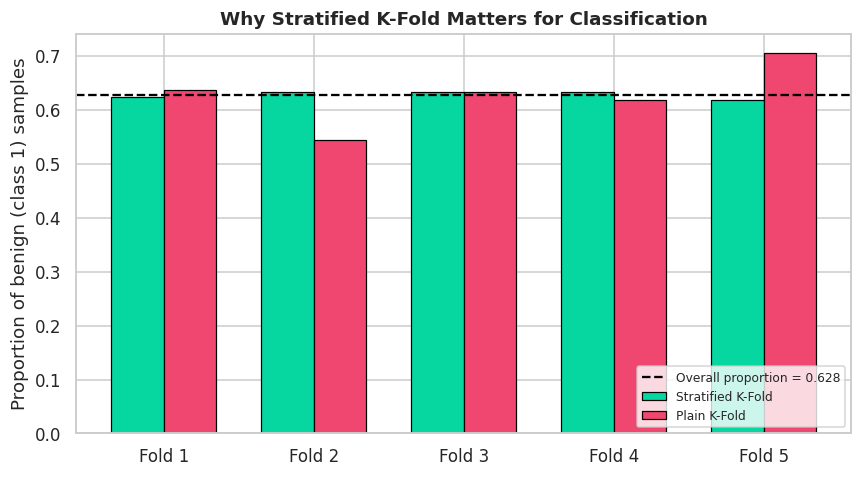

In [8]:
fold_idx = np.arange(1, 6)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(fold_idx - width/2, strat_props, width, label="Stratified K-Fold",
       color="#06d6a0", edgecolor="black", linewidth=0.8)
ax.bar(fold_idx + width/2, plain_props, width, label="Plain K-Fold",
       color="#ef476f", edgecolor="black", linewidth=0.8)

ax.axhline(overall_prop, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall proportion = {overall_prop:.3f}")

ax.set_xticks(fold_idx)
ax.set_xticklabels([f"Fold {i}" for i in fold_idx])
ax.set_ylabel("Proportion of benign (class 1) samples")
ax.set_title("Why Stratified K-Fold Matters for Classification", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## 5️⃣ Reflection ✍️

On question 1 (single-split vs. CV mean):

The cross-validated mean F1 (0.9606) was very close to yesterday's single-split score (0.9650) — only a 0.0044 difference. This tells me yesterday's validation split happened to be a fairly representative one, not a lucky or unlucky outlier. If the difference had been much larger, that would have been a sign that the single split gave a misleading picture of the model's true performance.

On question 2 (standard deviation):

The standard deviation across the 5 folds was ±0.0169, which is small relative to the mean score. A low standard deviation means the model performs consistently no matter which slice of the data is used for validation — so I can trust the mean score as a stable estimate. If the std had been large, it would mean the model's performance depends heavily on which specific data points end up in the validation fold, making any single score unreliable.

On question 3 (why stratification matters more on imbalanced/small data):

Looking at the chart, the plain K-Fold proportions swung from 0.544 to 0.706 across folds, while the stratified folds stayed tight between 0.623 and 0.632. On a small or imbalanced dataset, a bad random split could put almost none of the minority class into a fold — making that fold's score meaningless and skewing the average. Stratification guarantees every fold reflects the true class balance, so the cross-validation score stays a fair, honest estimate.

## ✅ Deliverable Checklist (Day 2)
- [ ] 🔄 Model evaluated with 5-fold cross-validation using `cross_val_score`
- [ ] 📊 Mean and standard deviation of fold scores reported
- [ ] 🔍 Cross-validated estimate compared to Day 1's single-split score, with explanation
- [ ] ⚖️ Stratified folds confirmed and explained for this classification task
- [ ] ✍️ Markdown reflection written in your own words
- [ ] 🚀 Notebook committed to GitHub with a clear commit message
